In [1]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Interpolation Function

In [59]:
# do on r, g, b channels independently
# interpolate to 1 line varying lat, single lon

def line_interpolate(lat_proj, lon_proj, rgb, 
                     lat_min, lat_max, lon_min, lon_max,
                     lat_min_box, lat_max_box, 
                     lon_min_box, lon_max_box,
                     site_name, folder_name, time_index, 
                     altitude):

    """
    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of plot_lat_lon()) 
        lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
        lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
        lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
        lon_max = maximum longitude to create grid for (should be common between the 2 cameras)
        lat_min_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
        lat_max_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
        lon_min_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
        lon_max_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
        time_index = for naming purposes 

    output:
        R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
    """

    # latitude and longitude arrays to define the interpolation grid
    lat_arr = np.arange(lat_min, lat_max, 0.5) # this is about close to the actual pixel resolution
    lon_arr = np.arange(lon_min, lon_max, 1) # 1 slice in longitude every 1 degree, maybe need to adjust this as projecting to higher altitudes


    print(f"Total {len(lon_arr)} longitudes to interpolate\n")
    R_peak_lat_arr = []
    
    # longitudes that have a peak latitude that we are saving (to handle the masking we do on the latitude ranges)
    R_lon_arr = []

    # separate into R, G, B channels
    R = rgb[:,:, 0]
    G = rgb[:,:, 1]
    B = rgb[:,:, 2]

    # ((site_name, altitude, time_index, longitude) --> (lon_slice, lat_slice, rgb_slice)) dict, keys = longitude
    # already include h,t and site_name in multithreading: (longitude, lon_slice, lat_slice, rgb_slice)
    interp_slice_arr = []

    # ((site_name, altitude, time_index, longitude) --> (lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile))
    # (longitude, lon_slice, lat_slice, rgb_slice)
    rgb_profile_arr = []

    # ((site_name, altitude, time_index) --> (r_lon_arr, R_peak_lat_arr)), keys=site_name, altitude_time_index
    # don't need this, just return directly 
    #peak_R_lat_lon_dict = {}
    
        
    for idx, single_lon in enumerate(lon_arr):

        # restrict to a longitude slice
        pixel_width = 1
        lon_pixel_spacing = 1
        lon_diff = np.abs(lon_proj - single_lon)
        slice_mask = lon_diff <= pixel_width * lon_pixel_spacing

        if np.sum(slice_mask) == 0:
            print(f"No points found in slice for longitude {single_lon}, skipping...")
            continue
    
        lon_slice = lon_proj[slice_mask]
        lat_slice = lat_proj[slice_mask]
        rgb_slice = rgb[slice_mask] # needed for plotting later, not for interpolation!
        R_slice = R[slice_mask]
        G_slice = G[slice_mask]
        B_slice = B[slice_mask]

        # save for plotting outside of multithreading
        #interp_slice_dict[(site_name, altitude, time_index, single_lon)] = [lon_slice, lat_slice, rgb_slice]
        interp_slice_arr.append([single_lon, lon_slice, lat_slice, rgb_slice, lon_proj, lat_proj, rgb]) # added og lon_proj, lat_proj, rgb so plotting bounds are nicer


        # flatten yknf and fsmi projected arrays + R + G + B arrays 
        #flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
        flattened_points = np.column_stack((lon_slice.flatten(), lat_slice.flatten())) # (N,2) pairs of (lat, lon)
        flattened_R = R_slice.flatten()
        flattened_G = G_slice.flatten()
        flattened_B = B_slice.flatten()

        # remove NaNs
        # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
        nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
        nan_mask_G = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_G))
        nan_mask_B = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_B))

        points_R_clean = flattened_points[nan_mask_R]
        values_R_clean = flattened_R[nan_mask_R]
        
        points_G_clean = flattened_points[nan_mask_G]
        values_G_clean = flattened_G[nan_mask_G]

        points_B_clean = flattened_points[nan_mask_B]
        values_B_clean = flattened_B[nan_mask_B]

        
        print(f"{idx}-- Longitude Interpolating: {single_lon}")
        single_lon_arr = single_lon * np.ones(np.shape(lat_arr)) # constant latitude, as many as there are latitudes to interpolate over 
        interp_locations = np.column_stack((single_lon_arr, lat_arr)) # array of (lon, lat) x-y pairs, longitude is constant so get line in lat

        # for Qhull errors (skip the )
        if len(points_R_clean) >= 3 and len(values_R_clean >= 3):   # minimum for 2D linear interpolation
            R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear')
        else:
            R_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

        if len(points_G_clean) >= 3 and len(values_G_clean >= 3):   # minimum for 2D linear interpolation
            G_intensity_profile = griddata(points_G_clean, values_G_clean, interp_locations, method='linear')
        else:
            G_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

        if len(points_B_clean) >= 3 and len(values_B_clean >= 3):   # minimum for 2D linear interpolation
            B_intensity_profile = griddata(points_B_clean, values_B_clean, interp_locations, method='linear')
        else:
            B_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

        # save for plotting outside of multithreading
        #rgb_profile_dict[(site_name, altitude, time_index, single_lon)] = [lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile]
        rgb_profile_arr.append([single_lon, lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile])
        
        # restrict the latitude to likely latitudes for the aurora (so gaussian can be fit)
        # NOT robust for different time stamps 
        # also remove NaNs so curve_fit will work (NaNs added if points to be interpolated outside of convex hull)
        lat_mask = (lat_arr >= lat_min_box - 2) & (lat_arr <= lat_max_box + 2)
        R_nan_mask = np.isfinite(R_intensity_profile)
        R_intensity_restricted = R_intensity_profile[lat_mask & R_nan_mask]
        lat_arr_restricted = lat_arr[lat_mask] 

        if R_intensity_restricted.size==0:
            print("No points in this latitude range for this longitude slice.\n")
            continue
        
        # jsut pick out the maximum intensity from the expected range of latitudes
        # indices for intensity & latitude should correspond 
        # make another array for the corresponding longitudes to the peak latitude (accounts for when hitting the exception intensity_restricted.size=0)
        # restrict the longitude so don't get meaningless peak intensities 
        if single_lon <= lon_max_box and single_lon >= lon_min_box:
            idx_peak_R = np.argmax(R_intensity_restricted)
            R_peak_lat_arr.append(lat_arr_restricted[idx_peak_R])
            R_lon_arr.append(single_lon)
            
    # remove outliers in peak latitude before line fitting
    # need to convert to np arrays
    R_peak_lat_arr = np.asarray(R_peak_lat_arr)
    R_lon_arr = np.asarray(R_lon_arr)

    # save for plotting outside of multithreading
    #peak_R_lat_lon_dict[(site_name, altitude, time_index)] = [R_lon_arr, R_peak_lat_arr] 

    # plot aurora image
    # plt.figure(figsize=(10,8))
    # plt.scatter(lon_proj.flatten(),lat_proj.flatten(),c=rgb.reshape(-1, 3)/256,s=1)
    # plt.ylabel("Latitude (deg)")
    # plt.xlabel("Longitude (deg)")
    # plt.title(f"Aurora with Fitted Lines")
    
    # # plot the peak points for R, G, B (raw)
    # plt.scatter(R_lon_arr, R_peak_lat_arr, color='red', label='Peak R', s=30)

    # plt.legend(
    #     fontsize=8,        
    #     markerscale=0.8,   
    #     handlelength=1,    # shorter legend lines
    #     handletextpad=0.4, # tighter text spacing
    #     borderpad=0.3      # smaller legend box padding
    # )
    # plt.show()

    return (interp_slice_arr, rgb_profile_arr,
           R_lon_arr, R_peak_lat_arr)

### Compute SSD function

In [60]:
# calculate the SSD for one single frame / timestamp for a given altitude to project to 
# - helper to do multithreading on both height and times for each height, time pairing in one pool
def compute_ssd_single_ht(
        h_target, time_index,
        full_azimuth_yknf, full_elevation_yknf, lat_yknf, lon_yknf,
        full_azimuth_fsmi, full_elevation_fsmi, lat_fsmi, lon_fsmi,
        yknf_110_mask, fsmi_110_mask,
        yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
       # yknf_box, fsmi_box 
    ):

    # project YKNF and FSMI to inputted altitude 
    yknf_lat_proj, yknf_lon_proj = project_lat_lon(
        full_azimuth_yknf, full_elevation_yknf,
        lat_yknf, lon_yknf, h_target, yknf_110_mask
    )

    fsmi_lat_proj, fsmi_lon_proj = project_lat_lon(
        full_azimuth_fsmi, full_elevation_fsmi,
        lat_fsmi, lon_fsmi, h_target, fsmi_110_mask
    )

    # extract RGB frames for given time step --> projected latitude and longitude are for entire hour! 
    site_name_yknf = "Yellowknife"
    site_name_fsmi = "Fort Smith"

    yknf_rgb, fsmi_rgb = mod_plot_lat_lon(
        yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
        time_index,
        site_name_yknf, site_name_fsmi,
        yknf_lat_proj, yknf_lon_proj,
        fsmi_lat_proj, fsmi_lon_proj,
        h_target
    )

    # interpolation region --> get overlap between lat/long region for YKNF and FSMI 
    lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
    lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
    lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
    lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

    
    # boxes to pick out where aurora is 
    yknf_lat_min_box, yknf_lat_max_box = 61, 66
    yknf_lon_min_box, yknf_lon_max_box = 242, 258

    fsmi_lat_min_box, fsmi_lat_max_box = 60, 65
    fsmi_lon_min_box, fsmi_lon_max_box = 244, 257

    global_lat_min_box = max(yknf_lat_min_box, fsmi_lat_min_box)
    global_lat_max_box = min(yknf_lat_max_box, fsmi_lat_max_box)
    global_lon_min_box = max(yknf_lon_min_box, fsmi_lon_min_box)
    global_lon_max_box = min(yknf_lon_max_box, fsmi_lon_max_box)

    # interpolate YKNF (only care about the yknf_R_peak_lat_arr for ssd calculations)
    (yknf_intep_slice_arr, yknf_rgb_profile_arr, yknf_lon, yknf_R_peak_lat_arr) = line_interpolate(
        yknf_lat_proj, yknf_lon_proj, yknf_rgb,
        lat_min, lat_max, lon_min, lon_max,
        global_lat_min_box, global_lat_max_box,
        global_lon_min_box, global_lon_max_box,
        "yknf", "yknf_intensity_profiles",
        time_index, h_target
    )

    # interpolate FSMI (only care about the fsmi_R_peak_lat_arr for ssd calculations)
    (fsmi_intep_slice_arr, fsmi_rgb_profile_arr, fsmi_lon, fsmi_R_peak_lat_arr) = line_interpolate(
        fsmi_lat_proj, fsmi_lon_proj, fsmi_rgb,
        lat_min, lat_max, lon_min, lon_max,
        global_lat_min_box, global_lat_max_box,
        global_lon_min_box, global_lon_max_box,
        "fsmi", "fsmi_intensity_profiles",
        time_index, h_target
    )

    # ssd calculations 
    ssd = np.nansum((yknf_R_peak_lat_arr - fsmi_R_peak_lat_arr) ** 2)
    return {
        "ssd": ssd,
        "yknf_interp": yknf_intep_slice_arr,
        "yknf_profiles": yknf_rgb_profile_arr,
        "yknf_lon": yknf_lon,
        "yknf_peak_lat": yknf_R_peak_lat_arr,
        "fsmi_interp": fsmi_intep_slice_arr,
        "fsmi_profiles": fsmi_rgb_profile_arr,
        "fsmi_lon": fsmi_lon,
        "fsmi_peak_lat": fsmi_R_peak_lat_arr,
    }


In [ ]:
yknf_box_dict:

### Loop through proj altitudes and timestamps

In [67]:
# needed yknf and fsmi arrs: lat, long, elevation, azimuth, yknf110 & fsmi110 mask to restrict plots
lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


# all the altitudes and time stamps to cycle through 
h_arr = [100000, 120000, 140000, 160000, 180000, 200000, 220000, 240000, 260000] #, 280000] #, 300000, 320000, 340000] #, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340]
t_arr = [100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200] #, 210, 220, 230, 240, 250, 260, 270] # 100 --> 270
jobs = [(h, t) for h in h_arr for t in t_arr] # needed to parallelize over all height, time pairings 
correlation_dict = {}

# create worker ONCE, not for every altitude (like u would if parallelizing only over time)
# prefill arguments for the computer_ssd_single_time function later, since in loop only h, t are changed in each iteration (leave h, t out for now)
worker = partial(
    compute_ssd_single_ht,
    full_azimuth_yknf=full_azimuth_yknf,
    full_elevation_yknf=full_elevation_yknf,
    lat_yknf=lat_yknf,
    lon_yknf=lon_yknf,
    full_azimuth_fsmi=full_azimuth_fsmi,
    full_elevation_fsmi=full_elevation_fsmi,
    lat_fsmi=lat_fsmi,
    lon_fsmi=lon_fsmi,
    yknf_110_mask=yknf_110_mask,
    fsmi_110_mask=fsmi_110_mask,
    yknf_rgb_asi_ds=yknf_rgb_asi_ds,
    fsmi_rgb_asi_ds=fsmi_rgb_asi_ds
)

# parallelize over all (h, t) pairs --> called worker(h, t) in separate processes simultaneously
# uses all avail cores, specify how many cores to use with arg: max_workers=4 for 4 cores 
max_workers = os.cpu_count() - 2 # help with RAM usage 
results_dict = {} 

with ThreadPoolExecutor(max_workers=max_workers) as ex:
    # submit all jobs
    futures = {ex.submit(worker, *args): args for args in jobs}

    # collect results as they complete, updating tqdm
    for f in tqdm(as_completed(futures), total=len(futures), desc="Computing SSD grid"):
        results_dict[futures[f]] = f.result() # collects ALL the values returned from compute_ssd_single_ht()
        
# results are flat bc of (h, t) pairings --> convert to matrix 
H = len(h_arr)
T = len(t_arr)
ssd_matrix = np.zeros((H, T)) # init w zeroes

# mapping for faster lookup
h_to_i = {h: i for i, h in enumerate(h_arr)} # creates {100000:0, 120000:1, 140000:2, etc...}
t_to_j = {t: j for j, t in enumerate(t_arr)} # creates {100:0, 110:1, 120:2, etc...}

# fill ssd matrix
for (h, t), val in results_dict.items():
    ssd_matrix[h_to_i[h], t_to_j[t]] = val["ssd"]

# make correlation_dict[h] = list of T SSD values for that altitude
correlation_dict = {
    h: list(ssd_matrix[h_to_i[h], :]) for h in h_arr
}


Computing SSD grid:   0%|          | 0/99 [00:00<?, ?it/s]

Total 48 longitudes to interpolate

Total 48 longitudes to interpolate

Total 59 longitudes to interpolate

Total 48 longitudes to interpolate

Total 48 longitudes to interpolate

Total 48 longitudes to interpolate

Total 48 longitudes to interpolate

0-- Longitude Interpolating: 221.9626667962198
Total 48 longitudes to interpolate

0-- Longitude Interpolating: 216.30610847339244
Total 48 longitudes to interpolate

0-- Longitude Interpolating: 221.9626667962198
Total 59 longitudes to interpolate

0-- Longitude Interpolating: 221.9626667962198
No points in this latitude range for this longitude slice.

Total 59 longitudes to interpolate

No points in this latitude range for this longitude slice.

0-- Longitude Interpolating: 221.9626667962198
0-- Longitude Interpolating: 221.9626667962198
No points in this latitude range for this longitude slice.

Total 48 longitudes to interpolate

0-- Longitude Interpolating: 221.9626667962198
Total 48 longitudes to interpolate

0-- Longitude Interpol

In [68]:
# # alt=100km, time_idx=100, returns the yknf_lon_slice, yknf_lat_slice, yknf_rgb_slice for lon221.9626667962198
# results_dict[(100000, 100)]["yknf_interp"]

# #results_dict[(100000, 100)]["yknf_peak_lat"]

In [74]:
ssd_matrix

array([[40.75, 55.75, 51.  , 23.5 , 86.  , 64.  , 57.75, 32.75, 23.75,
        14.75, 33.75],
       [36.25, 63.25, 16.5 , 21.5 , 23.25, 39.25, 23.  , 13.75,  6.25,
        22.75, 30.5 ],
       [52.5 , 38.75, 32.75, 40.  , 33.75, 61.  , 34.75, 23.  , 16.25,
        23.5 , 24.25],
       [17.75, 17.  , 13.  , 20.5 ,  6.25, 20.  , 29.75, 15.5 , 10.5 ,
         2.25,  5.75],
       [26.  , 22.25, 17.75, 21.75, 15.25,  9.  , 14.  , 15.  ,  4.  ,
         3.  ,  4.25],
       [19.25, 14.25, 35.5 , 24.  , 22.25, 17.  , 33.75, 13.5 , 17.  ,
         5.75,  7.25],
       [11.75, 21.75, 31.75, 34.  , 17.5 , 31.25, 22.75, 17.  , 25.75,
         9.5 ,  7.75],
       [22.5 , 16.25, 24.25, 22.5 , 12.5 , 11.75, 29.  , 14.  , 17.  ,
        12.25, 13.5 ],
       [41.75, 25.25, 32.25, 25.75,  9.  , 20.5 , 27.75, 25.25, 13.75,
        15.25,  4.75]])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Plotting SSD Matrix

In [72]:
%matplotlib inline

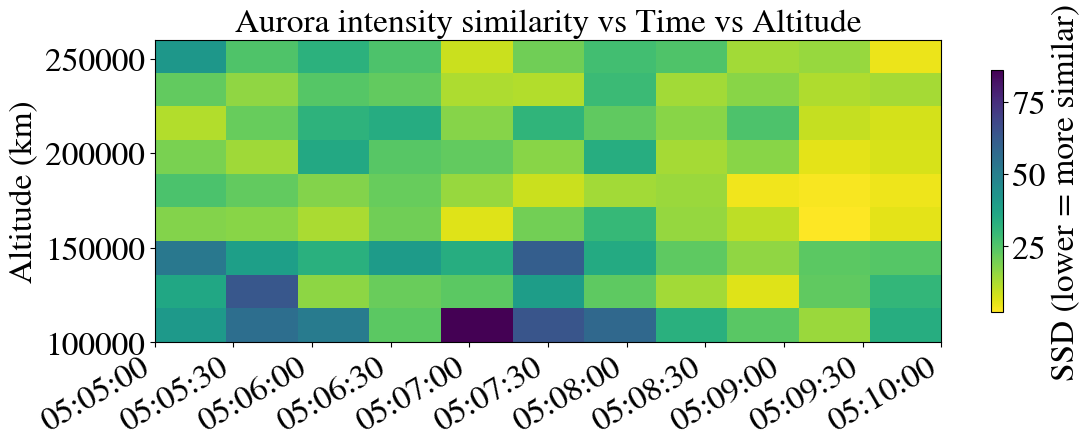

In [73]:
# prepare altitude + time arrays
altitude_arr = list(correlation_dict.keys())
example_alt = altitude_arr[0]
#time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# computer number of altitudes and number of times from ssd_matrix
n_alts, n_times = ssd_matrix.shape

# generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# plot the correlation matrix over time and projected altitude 
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    ssd_matrix,
    origin='lower',
    aspect='auto',
    extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
    cmap='viridis_r'
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('SSD (lower = more similar)')

ax.set_xticks(np.arange(n_times))
ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
ax.set_ylabel('Altitude (km)')
ax.set_title('Aurora intensity similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()


### Time String Generation

In [41]:
t_str_dict = {}
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_dict[time]= time_obj.strftime("%H:%M:%S")


### Making intermediate plots

In [70]:
# turn off interactive display to save memory
#%matplotlib agg

In [66]:
for (h, t), result in results_dict.items():

    ## plots of longitude slices where interpolation is done 
    yknf_interp = result["yknf_interp"]
    out_dir = "yknf_interp_slice"
    os.makedirs(out_dir, exist_ok=True)
    for (longitude, lon_slice, lat_slice, rgb_slice, lon_proj, lat_proj, rgb) in yknf_interp:
        # choose a filename — example uses h_target + time_str
        filename = f"interp_{h/1000.0}km_{t_str_dict[t]}_lon{longitude:.2f}.jpg"
        filepath = os.path.join(out_dir, filename)
        
        # create and save figure
        fig1, ax1 = plt.subplots(figsize=(5,5))
        scat2 = ax1.scatter(lon_proj.flatten(), lat_proj.flatten(),
                           c=rgb.reshape(-1,3)/256, alpha=0.05, s=1) #change the alpha value 
        scat1 = ax1.scatter(lon_slice.flatten(), lat_slice.flatten(),
                            c=rgb_slice.reshape(-1, 3)/256, s=1)
        ax1.set_ylabel("Latitude (deg)")
        ax1.set_xlabel("Longitude (deg)")
        plt.title(f"{h/1000.0}km, {t_str_dict[t]}, slice lon: {longitude:.2f}")
        
        plt.savefig(filepath, dpi=50, bbox_inches="tight")
        #plt.show()
        plt.close(fig1)
        print("Saved:", filepath)

    fsmi_interp = result["fsmi_interp"]
    out_dir = "fsmi_interp_slice"
    os.makedirs(out_dir, exist_ok=True)
    for (longitude, lon_slice, lat_slice, rgb_slice, lon_proj, lat_proj, rgb) in fsmi_interp:
        # choose a filename — example uses h_target + time_str
        filename = f"interp_{h/1000.0}km_{t_str_dict[t]}_lon{longitude:.2f}.jpg"
        filepath = os.path.join(out_dir, filename)
        
        # create and save figure
        fig1, ax1 = plt.subplots(figsize=(5,5))
        scat2 = ax1.scatter(lon_proj.flatten(), lat_proj.flatten(),
                           c=rgb.reshape(-1,3)/256, alpha=0.05, s=1) #change the alpha value 
        scat1 = ax1.scatter(lon_slice.flatten(), lat_slice.flatten(),
                            c=rgb_slice.reshape(-1, 3)/256, s=1)
        ax1.set_ylabel("Latitude (deg)")
        ax1.set_xlabel("Longitude (deg)")
        plt.title(f"{h/1000.0}km, {t_str_dict[t]}, slice lon: {longitude:.2f}")
        
        plt.savefig(filepath, dpi=50, bbox_inches="tight")
        #plt.show()
        plt.close(fig1)
        print("Saved:", filepath)

    
    ## plots of the intensity profiles 
    yknf_profiles = result["yknf_profiles"]
    out_dir = "yknf_intensity_profiles"
    os.makedirs(out_dir, exist_ok=True)
    for (longitude, lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile) in yknf_profiles:
        filename = f"yknf_intensity_{h/1000.0}km_{t_str_dict[t]}_lon{longitude:.2f}.jpg"
        filepath = os.path.join(out_dir, filename)
        plt.figure(figsize=(6,6))
        plt.plot(lat_arr, R_intensity_profile, 'r-', label='R channel')
        plt.plot(lat_arr, G_intensity_profile, 'g-', label='G channel')
        plt.plot(lat_arr, B_intensity_profile, 'b-', label='B channel')
        plt.xlabel('Latitude')
        plt.ylabel('Interpolated Intensity')
        plt.title(f'{h/1000.0}km, {t_str_dict[t]}, interp RGB at lon{longitude:.2f}')
        plt.legend()
        plt.grid(True)
        #plt.show()
        plt.savefig(filepath, dpi=100, bbox_inches="tight")
        plt.close() # memory!! 
        print("Saved:", filepath)

    fsmi_profiles = result["fsmi_profiles"]
    out_dir = "fsmi_intensity_profiles"
    os.makedirs(out_dir, exist_ok=True)
    for (longitude, lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile) in fsmi_profiles:
        filename = f"fsmi_intensity_{h/1000.0}km_{t_str_dict[t]}_lon{longitude:.2f}.jpg"
        filepath = os.path.join(out_dir, filename)
        plt.figure(figsize=(6,6))
        plt.plot(lat_arr, R_intensity_profile, 'r-', label='R channel')
        plt.plot(lat_arr, G_intensity_profile, 'g-', label='G channel')
        plt.plot(lat_arr, B_intensity_profile, 'b-', label='B channel')
        plt.xlabel('Latitude')
        plt.ylabel('Interpolated Intensity')
        plt.title(f'{h/1000.0}km, {t_str_dict[t]}, interp RGB at lon{longitude:.2f}')
        plt.legend()
        plt.grid(True)
        #plt.show()
        plt.savefig(filepath, dpi=100, bbox_inches="tight")
        plt.close() # memory!!
        print("Saved:", filepath)


    ## Plotting the final overlaid points identifying the aurora on the projected lat/lon plots 
    yknf_lon = result["yknf_lon"]
    yknf_peak_lat = result["yknf_peak_lat"]
    out_dir = "yknf_interp_line"
    os.makedirs(out_dir, exist_ok=True)
    filename = f"yknf_linefit_{h/1000.0}km_{t_str_dict[t]}.jpg"
    filepath = os.path.join(out_dir, filename)
    fig1, ax1 = plt.subplots(figsize=(8,8))
    scat1 = ax1.scatter(lon_proj.flatten(), lat_proj.flatten(),c=rgb.reshape(-1,3)/256, s=1) #change the alpha value 
    scat2 = ax1.scatter(yknf_lon, yknf_peak_lat, color='red', label='Peak R intensity', s=10)
    ax1.set_ylabel("Latitude (deg)")
    ax1.set_xlabel("Longitude (deg)")
    plt.title(f"{h/1000.0}km, {t_str_dict[t]}, slice lon: {longitude:.2f}")
    plt.legend(
        fontsize=8,        
        markerscale=0.8,   
        handlelength=1,    # shorter legend lines
        handletextpad=0.4, # tighter text spacing
        borderpad=0.3      # smaller legend box padding
    )
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
   # plt.show()
    plt.close(fig1)
    print("Saved:", filepath)

    fsmi_lon = result["fsmi_lon"]
    yknf_peak_lat = result["fsmi_peak_lat"]
    out_dir = "fsmi_interp_line"
    os.makedirs(out_dir, exist_ok=True)
    filename = f"fsmi_linefit_{h/1000.0}km_{t_str_dict[t]}.jpg"
    filepath = os.path.join(out_dir, filename)
    fig1, ax1 = plt.subplots(figsize=(8,8))
    scat1 = ax1.scatter(lon_proj.flatten(), lat_proj.flatten(),c=rgb.reshape(-1,3)/256, s=1) #change the alpha value 
    scat2 = ax1.scatter(fsmi_lon, fsmi_peak_lat, color='red', label='Peak R intensity', s=10)
    ax1.set_ylabel("Latitude (deg)")
    ax1.set_xlabel("Longitude (deg)")
    plt.title(f"{h/1000.0}km, {t_str_dict[t]}, slice lon: {longitude:.2f}")
    plt.legend(
        fontsize=8,        
        markerscale=0.8,   
        handlelength=1,    # shorter legend lines
        handletextpad=0.4, # tighter text spacing
        borderpad=0.3      # smaller legend box padding
    )
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
  #  plt.show()
    plt.close(fig1)
    print("Saved:", filepath)


    break
    
    


Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon216.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon217.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon218.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon219.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon220.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon221.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon222.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon223.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon224.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon225.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon226.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon227.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon228.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon229.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon230.31.jpg
Saved: yknf_interp_slice/interp_120.0km_05:05:30_lon231

In [36]:
t_str_dict

{100: '05:05:00', 110: '05:05:30'}

In [ ]:
# [(latmin, latmax), (lonmin, lonmax)]
aurora_bound_dict[(100000, 100)] = [(61, 64), (240, 260)]
aurora_bound_dict[(100000, 200)] = [(61, 65), (240, 260)]
aurora_bound_dict[(100000, 100)] = [(61, 65), (240, 260)]